In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    label_binarize
)

from sklearn.pipeline import Pipeline

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

import joblib

In [3]:
df = pd.read_csv("adult.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [4]:
df.columns = df.columns.str.replace(
    ".",
    "_",
    regex=False
)

print(df.columns)

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='str')


In [5]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.2 MB


In [7]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [8]:
df.replace("?", np.nan, inplace=True)

df.dropna(inplace=True)

print("Dataset Shape:", df.shape)

Dataset Shape: (30162, 15)


In [9]:
# Low Education Risk

df["low_education_risk"] = np.where(
    df["education_num"] <= 9,
    1,
    0
)

# Underemployment Risk

df["underemployment_risk"] = np.where(
    df["hours_per_week"] < 30,
    1,
    0
)

# Wealth Risk

df["wealth_risk"] = np.where(
    df["capital_gain"] == 0,
    1,
    0
)

print("Feature Engineering Completed")

Feature Engineering Completed


In [10]:
low_income_jobs = [
    "Handlers-cleaners",
    "Other-service",
    "Priv-house-serv",
    "Farming-fishing"
]

df["occupation_risk"] = df["occupation"].apply(
    lambda x: 1 if x in low_income_jobs else 0
)

print("Occupation Risk Added")

Occupation Risk Added


In [11]:
unstable_status = [
    "Never-married",
    "Separated",
    "Divorced"
]

df["family_instability_risk"] = df["marital_status"].apply(
    lambda x: 1 if x in unstable_status else 0
)

print("Family Instability Risk Added")

Family Instability Risk Added


In [12]:
df["poverty_score"] = (

    df["low_education_risk"] * 20 +

    df["underemployment_risk"] * 20 +

    df["wealth_risk"] * 15 +

    df["occupation_risk"] * 20 +

    df["family_instability_risk"] * 10
)

df["poverty_score"] += np.where(
    df["income"] == "<=50K",
    35,
    0
)

print("Poverty Score Created")

Poverty Score Created


In [13]:
def classify_risk(score):

    if score >= 70:
        return "High Risk"

    elif score >= 40:
        return "Moderate Risk"

    else:
        return "Low Risk"


df["poverty_trap_risk"] = df["poverty_score"].apply(
    classify_risk
)

print("Poverty Risk Labels Generated")

Poverty Risk Labels Generated


In [14]:
df["poverty_trap_risk"].value_counts()

poverty_trap_risk
High Risk        14233
Moderate Risk     8595
Low Risk          7334
Name: count, dtype: int64

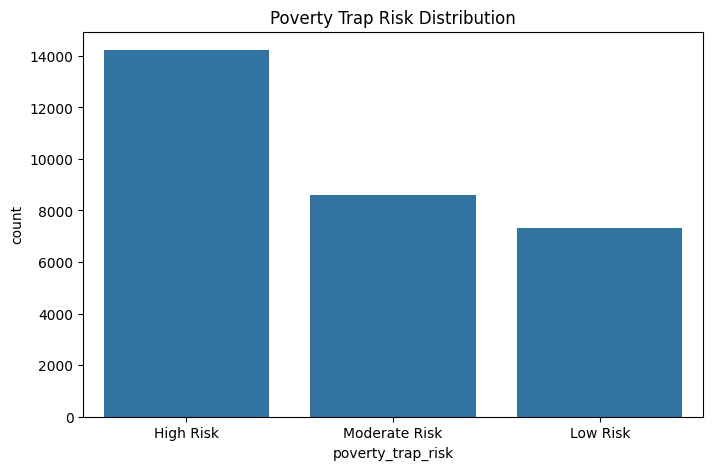

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="poverty_trap_risk",
    data=df
)

plt.title("Poverty Trap Risk Distribution")

plt.show()

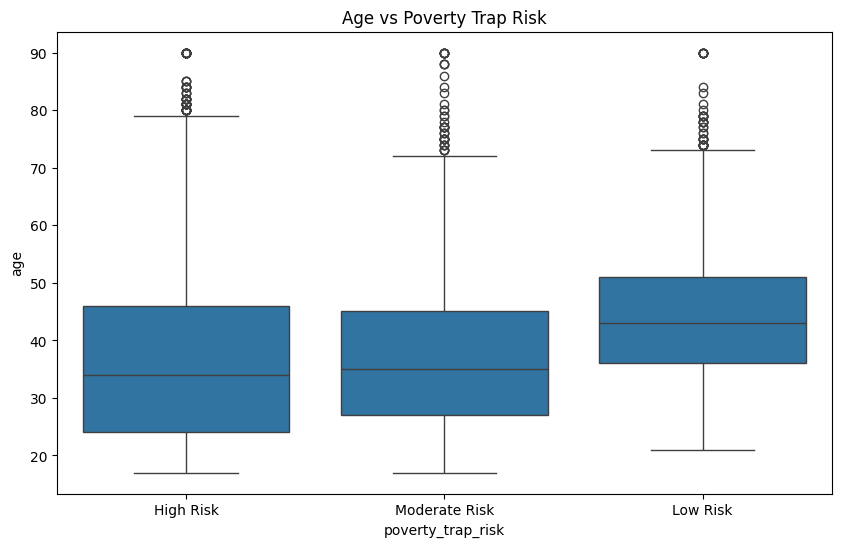

In [16]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="poverty_trap_risk",
    y="age",
    data=df
)

plt.title("Age vs Poverty Trap Risk")

plt.show()

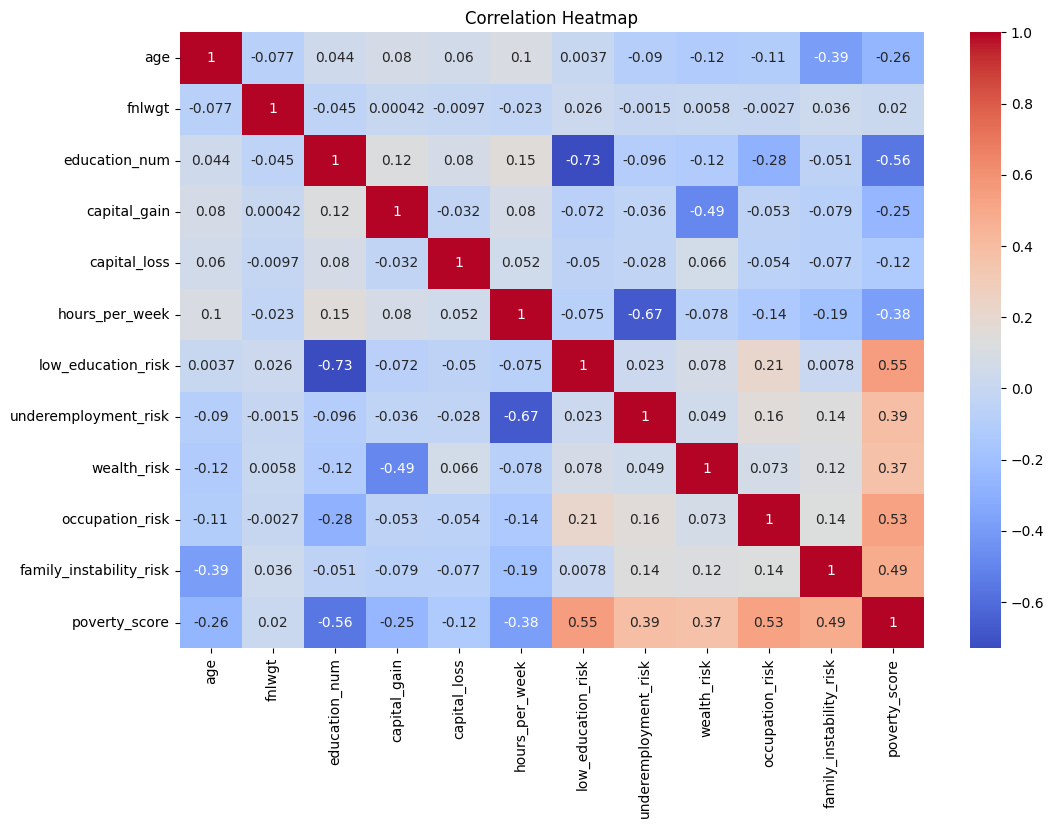

In [17]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [18]:
X = df.drop(
    [
        "poverty_trap_risk",
        "poverty_score",
        "income"
    ],
    axis=1
)

y = df["poverty_trap_risk"]

print("Features and Target Prepared")

Features and Target Prepared


In [19]:
categorical_cols = X.select_dtypes(
    include=["object"]
).columns

numeric_cols = X.select_dtypes(
    exclude=["object"]
).columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumeric Columns:")
print(numeric_cols)

Categorical Columns:
Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country'],
      dtype='str')

Numeric Columns:
Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week', 'low_education_risk', 'underemployment_risk',
       'wealth_risk', 'occupation_risk', 'family_instability_risk'],
      dtype='str')


C:\Users\lohit\AppData\Local\Temp\ipykernel_12264\2063170803.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(


In [20]:
preprocessor = ColumnTransformer(

    transformers=[

        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        ),

        (
            "num",
            StandardScaler(),
            numeric_cols
        )
    ]
)

print("Preprocessor Created")

Preprocessor Created


In [21]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print("Train Test Split Completed")

Train Test Split Completed


In [22]:
rf_model = Pipeline([

    ("preprocessor", preprocessor),

    (
        "classifier",

        RandomForestClassifier(
            n_estimators=200,
            max_depth=12,
            min_samples_split=5,
            random_state=42
        )
    )
])

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained")

Random Forest Model Trained


In [23]:
rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8544670976297033


In [24]:
print(classification_report(
    y_test,
    rf_pred
))

               precision    recall  f1-score   support

    High Risk       0.89      1.00      0.94      2847
     Low Risk       0.76      0.66      0.70      1467
Moderate Risk       0.85      0.79      0.82      1719

     accuracy                           0.85      6033
    macro avg       0.84      0.81      0.82      6033
 weighted avg       0.85      0.85      0.85      6033



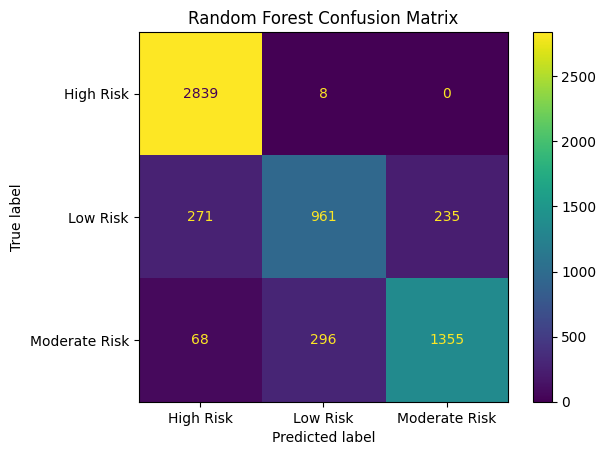

In [25]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf_model.classes_
)

disp.plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

In [26]:
gb_model = Pipeline([

    ("preprocessor", preprocessor),

    (
        "classifier",

        GradientBoostingClassifier(
            random_state=42
        )
    )
])

gb_model.fit(X_train, y_train)

print("Gradient Boosting Model Trained")

Gradient Boosting Model Trained


In [27]:
gb_pred = gb_model.predict(X_test)

gb_accuracy = accuracy_score(
    y_test,
    gb_pred
)

print("Gradient Boosting Accuracy:", gb_accuracy)

Gradient Boosting Accuracy: 0.8630863583623405


In [28]:
print(classification_report(
    y_test,
    gb_pred
))

               precision    recall  f1-score   support

    High Risk       0.90      0.99      0.94      2847
     Low Risk       0.77      0.68      0.72      1467
Moderate Risk       0.86      0.81      0.84      1719

     accuracy                           0.86      6033
    macro avg       0.85      0.83      0.83      6033
 weighted avg       0.86      0.86      0.86      6033



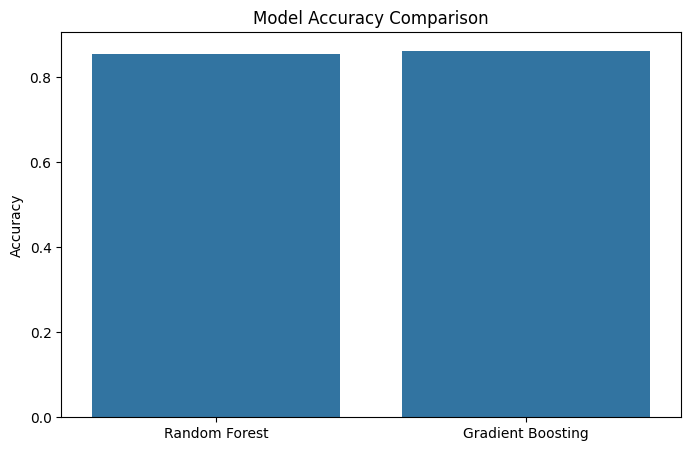

In [29]:
models = [
    "Random Forest",
    "Gradient Boosting"
]

accuracies = [
    rf_accuracy,
    gb_accuracy
]

plt.figure(figsize=(8,5))

sns.barplot(
    x=models,
    y=accuracies
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

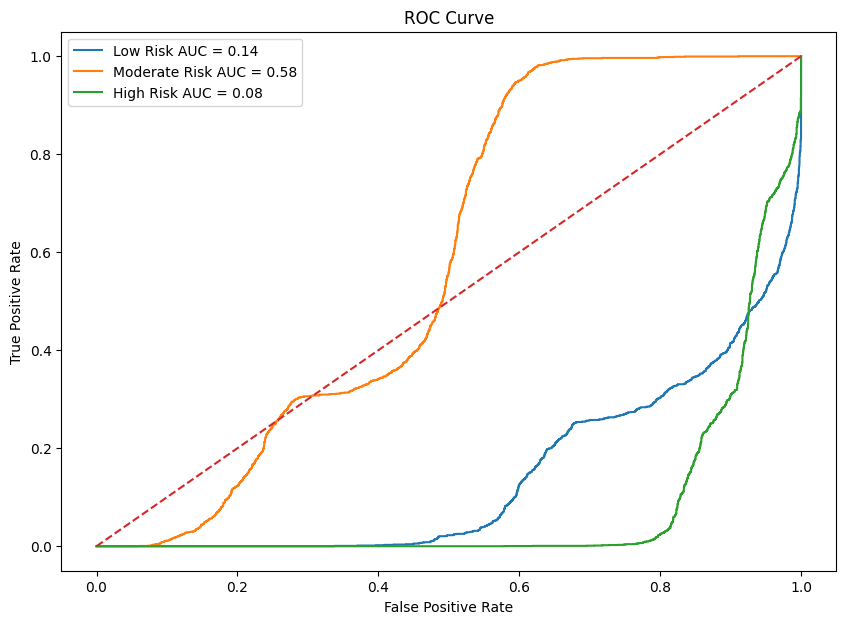

In [30]:
y_test_bin = label_binarize(

    y_test,

    classes=[
        "Low Risk",
        "Moderate Risk",
        "High Risk"
    ]
)

rf_probs = rf_model.predict_proba(X_test)

plt.figure(figsize=(10,7))

for i, class_name in enumerate([
    "Low Risk",
    "Moderate Risk",
    "High Risk"
]):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        rf_probs[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} AUC = {roc_auc:.2f}"
    )

plt.plot([0,1], [0,1], linestyle="--")

plt.title("ROC Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

In [31]:
encoded_cat_features = rf_model.named_steps[
    "preprocessor"
].named_transformers_[
    "cat"
].get_feature_names_out(categorical_cols)

all_features = np.concatenate([
    encoded_cat_features,
    numeric_cols
])

importances = rf_model.named_steps[
    "classifier"
].feature_importances_

feature_importance_df = pd.DataFrame({

    "Feature": all_features,

    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df.head(15)

,Feature,Importance
104,low_education_risk,0.164252
100,education_num,0.162706
107,occupation_risk,0.078947
18,education_HS-grad,0.060173
103,hours_per_week,0.054943
101,capital_gain,0.049593
25,marital_status_Married-civ-spouse,0.047233
105,underemployment_risk,0.044978
108,family_instability_risk,0.039476
37,occupation_Other-service,0.034932


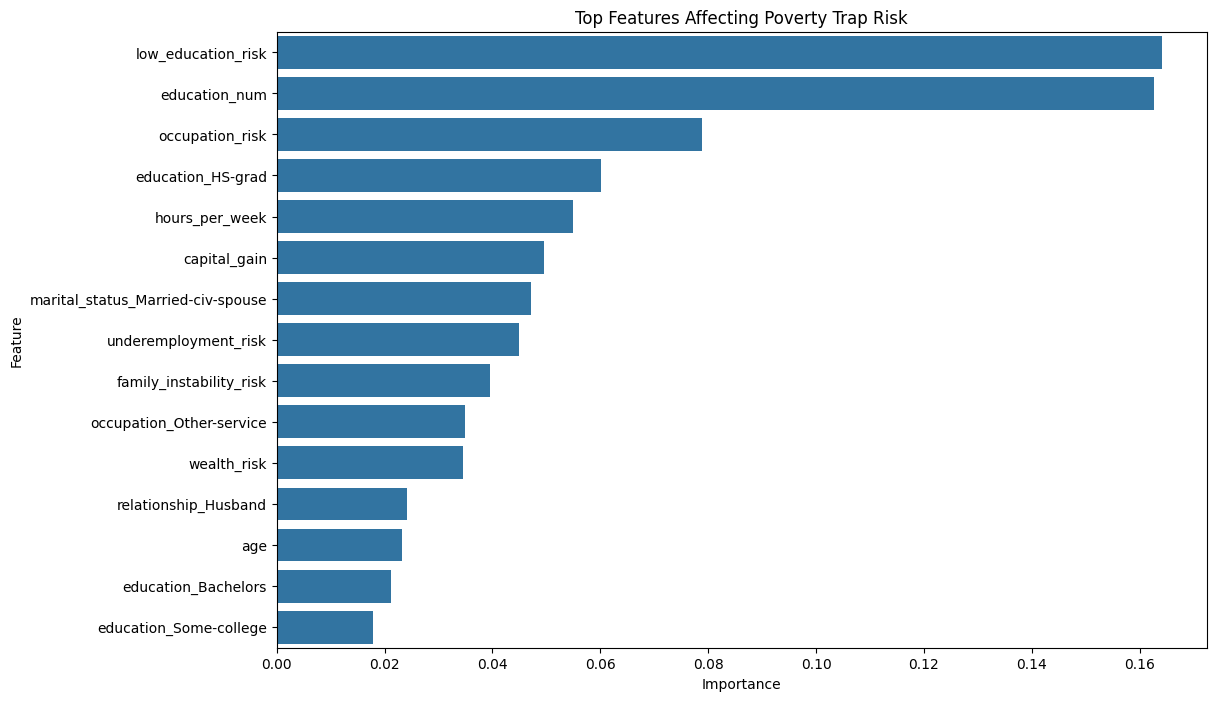

In [32]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(12,8))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title("Top Features Affecting Poverty Trap Risk")

plt.show()

In [33]:
joblib.dump(
    rf_model,
    "poverty_trap_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [34]:


sample_family = pd.DataFrame({

    "age": [35],

    "workclass": ["Private"],

    "fnlwgt": [120000],

    "education": ["HS-grad"],

    "education_num": [9],

    "marital_status": ["Married-civ-spouse"],

    "occupation": ["Other-service"],

    "relationship": ["Husband"],

    "race": ["White"],

    "sex": ["Male"],

    "capital_gain": [0],

    "capital_loss": [0],

    "hours_per_week": [25],

    "native_country": ["United-States"],

    "income": ["<=50K"],

    "low_education_risk": [1],

    "underemployment_risk": [1],

    "wealth_risk": [1],

    "occupation_risk": [1],

    "family_instability_risk": [0],

    "poverty_score": [90]
})

sample_family


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,...,capital_loss,hours_per_week,native_country,income,low_education_risk,underemployment_risk,wealth_risk,occupation_risk,family_instability_risk,poverty_score
0,35,Private,120000,HS-grad,9,Married-civ-spouse,Other-service,Husband,White,Male,...,0,25,United-States,<=50K,1,1,1,1,0,90


In [35]:
sample_family["low_education_risk"] = np.where(
    sample_family["education_num"] <= 9,
    1,
    0
)

sample_family["underemployment_risk"] = np.where(
    sample_family["hours_per_week"] < 30,
    1,
    0
)

sample_family["wealth_risk"] = np.where(
    sample_family["capital_gain"] == 0,
    1,
    0
)

sample_family["occupation_risk"] = sample_family[
    "occupation"
].apply(
    lambda x: 1 if x in low_income_jobs else 0
)

sample_family["family_instability_risk"] = sample_family[
    "marital_status"
].apply(
    lambda x: 1 if x in unstable_status else 0
)

sample_family

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,...,capital_loss,hours_per_week,native_country,income,low_education_risk,underemployment_risk,wealth_risk,occupation_risk,family_instability_risk,poverty_score
0,35,Private,120000,HS-grad,9,Married-civ-spouse,Other-service,Husband,White,Male,...,0,25,United-States,<=50K,1,1,1,1,0,90


In [36]:
prediction = rf_model.predict(sample_family)

prediction_prob = rf_model.predict_proba(sample_family)

print("Predicted Poverty Trap Risk:")

print(prediction[0])

Predicted Poverty Trap Risk:
High Risk


In [37]:
for risk, prob in zip(
    rf_model.classes_,
    prediction_prob[0]
):

    print(f"{risk}: {prob:.2f}")

High Risk: 0.93
Low Risk: 0.02
Moderate Risk: 0.05


In [38]:
import joblib

joblib.dump(rf_model, "model.pkl")

['model.pkl']